(1690, 2945, 3)


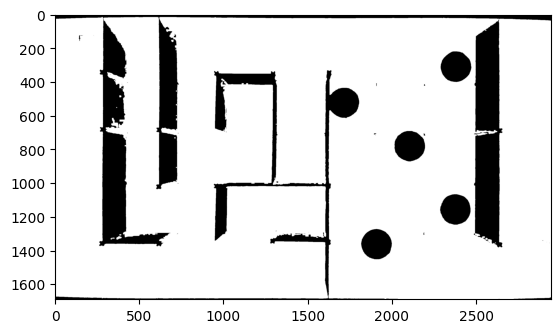

In [122]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Open an image
IMAGE_FILE = "continuous_example_1.jpeg"
thresh = 128
maxval = 255

img_maze = cv2.imread(IMAGE_FILE)
img_hsv = cv2.cvtColor(img_maze[260:1950, 480:3425], cv2.COLOR_BGR2HSV)

hsv_mask = cv2.inRange(img_hsv, (4,38,101), (27,255, 255))

_, threshed = cv2.threshold(hsv_mask, thresh, maxval, cv2.THRESH_BINARY)
threshed_3_channel = cv2.cvtColor(threshed, cv2.COLOR_GRAY2BGR)

kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), np.uint8)
threshed_3_channel = cv2.dilate(threshed_3_channel, kernel, iterations = 2)

print(threshed_3_channel.shape)
pts1 = np.float32()

# plt.figure(figsize = (9,5))
plt.imshow(threshed_3_channel)
plt.show()

In [123]:
# Task 2.1 (3 marks):  Complete the graph class

class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(node_id, x, y)
            self.edges[node_id] = {}
        pass

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 in self.nodes and node_id2 in self.nodes:
            self.edges[node_id1][node_id2] = weight
            self.edges[node_id2][node_id1] = weight
        pass

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
            del self.edges[node_id2][node_id1]
        pass
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            return self.edges[node_id1][node_id2]
        return None 

In [124]:
def path_clear(image, x1, y1, x2, y2):
    height, width = image.shape[:2]
    for t in range(101):
        t /= 100.0
        x = int(x1 * (1 - t) + x2 * t)
        y = int(y1 * (1 - t) + y2 * t)
        x = max(0, min(x, width - 1))  # Clamp x
        y = max(0, min(y, height - 1))  # Clamp y
        if (image[y, x][0] == 0 and image[y, x][1] == 0 and image[y, x][2] == 0) or (image[y, x][0] == 255 and image[y, x][1] == 0 and image[y, x][2] == 0):  # Black or red
            return False
    return True


Total nodes: 91
Node IDs with positions:
ID: 0, Position: (150, 150)
ID: 1, Position: (400, 150)
ID: 2, Position: (650, 150)
ID: 3, Position: (900, 150)
ID: 4, Position: (1150, 150)
ID: 5, Position: (1400, 150)
ID: 6, Position: (1650, 150)
ID: 7, Position: (1900, 150)
ID: 8, Position: (2150, 150)
ID: 9, Position: (2400, 150)
ID: 10, Position: (2650, 150)
ID: 11, Position: (2900, 150)
ID: 12, Position: (3150, 150)
ID: 13, Position: (150, 400)
ID: 14, Position: (400, 400)
ID: 15, Position: (650, 400)
ID: 16, Position: (900, 400)
ID: 17, Position: (1150, 400)
ID: 18, Position: (1400, 400)
ID: 19, Position: (1650, 400)
ID: 20, Position: (1900, 400)
ID: 21, Position: (2150, 400)
ID: 22, Position: (2400, 400)
ID: 23, Position: (2650, 400)
ID: 24, Position: (2900, 400)
ID: 25, Position: (3150, 400)
ID: 26, Position: (150, 650)
ID: 27, Position: (400, 650)
ID: 28, Position: (650, 650)
ID: 29, Position: (900, 650)
ID: 30, Position: (1150, 650)
ID: 31, Position: (1400, 650)
ID: 32, Position: (16

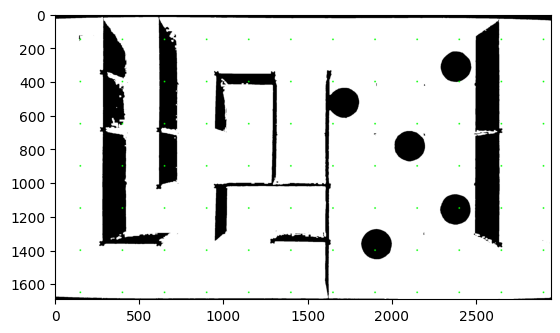

In [125]:
bfs_image = threshed_3_channel.copy()
bfs_graph = Graph()

node_id = 0
size_of_node_grid = 20

# Initialize the size of the array
img_width = bfs_image.shape[1]
img_height = bfs_image.shape[0]

# Smaller grid spacing for more nodes
grid_spacing_x = 250
grid_spacing_y = 250

# Get nodes
dictionary = bfs_graph.get_nodes()
height = 7  # Adjust to fit your maze dimensions
width = 12  # Adjust to fit your maze dimensions
border = 150

# Generate nodes
for i in range(height):
    for j in range(width + 1):        
        x = border + j * grid_spacing_y
        y = border + i * grid_spacing_x
        bfs_graph.add_node(node_id, x, y)
        node_id += 1

print("Total nodes:", node_id)
print("Node IDs with positions:")
for node_id, node in dictionary.items():
    print(f"ID: {node_id}, Position: {node.get_point()}")

# Horizontal Edges
for i in range(0, node_id - 1, width + 1):
    for j in range(width):
        node_id1 = i + j
        node_id2 = node_id1 + 1
        if node_id2 < node_id:  # Ensure node_id2 is within bounds
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            if path_clear(bfs_image, x1, y1, x2, y2):
                bfs_graph.add_edge(node_id1, node_id2, 1)

# Vertical Edges
for i in range(width + 1):
    for j in range(0, node_id - width - 1, width + 1):
        node_id1 = i + j
        node_id2 = node_id1 + width + 1
        if node_id2 < node_id:  # Ensure node_id2 is within bounds
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            if path_clear(bfs_image, x1, y1, x2, y2):
                bfs_graph.add_edge(node_id1, node_id2, 1)
    
# Display nodes            
for node_id in dictionary:
    x, y = dictionary[node_id].get_point()
    cv2.circle(bfs_image, (x, y), 5, (0, 255, 0), -1)

# Display Resulting Image
plt.imshow(bfs_image)
plt.show()


In [126]:
# BFS Pathfinding
start_id = 4 * (width + 1) + 1  # Start node ID for (4,1) = 53
goal_id = 6 * (width + 1) + 4  # Goal node ID for (8,0) = 82

print(f"Start ID: {start_id}, Goal ID: {goal_id}")
print(f"Start Position: {dictionary[start_id].get_point()}")
print(f"Goal Position: {dictionary[goal_id].get_point()}")

def bfs(graph, start, goal):
    from collections import deque
    queue = deque([start])
    visited = {start: None}
    
    while queue:
        current = queue.popleft()
        
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = visited[current]
            return path[::-1]  # Reverse the path
        
        for neighbor in graph.edges[current]:
            if neighbor not in visited:
                visited[neighbor] = current
                queue.append(neighbor)
    
    return None

# Perform BFS
path = bfs(bfs_graph, start_id, goal_id)

if path:
    # Draw the path
    for i in range(len(path) - 1):
        node_id1 = path[i]
        node_id2 = path[i + 1]
        x1, y1 = dictionary[node_id1].get_point()
        x2, y2 = dictionary[node_id2].get_point()
        cv2.line(bfs_image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Draw path in blue
    
    plt.imshow(bfs_image)
    plt.show()
else:
    print("No path found")


Start ID: 53, Goal ID: 82
Start Position: (400, 1150)
Goal Position: (1150, 1650)
No path found
